Transformation = preparing data (like cleaning & organizing toys) so your ML model can play with it properly! 

In [1]:
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
df = pd.read_csv('sample_dataset.csv').iloc[:, 0:5].dropna()

In [3]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
8,13.00,21.82,87.50,519.8,0.12730
13,15.85,23.95,103.70,782.7,0.08401
14,13.73,22.61,93.60,578.3,0.11310
...,...,...,...,...,...
549,10.82,24.21,68.89,361.6,0.08192
550,10.86,21.48,68.51,360.5,0.07431
560,14.05,27.15,91.38,600.4,0.09929
564,21.56,22.39,142.00,1479.0,0.11100


<Axes: >

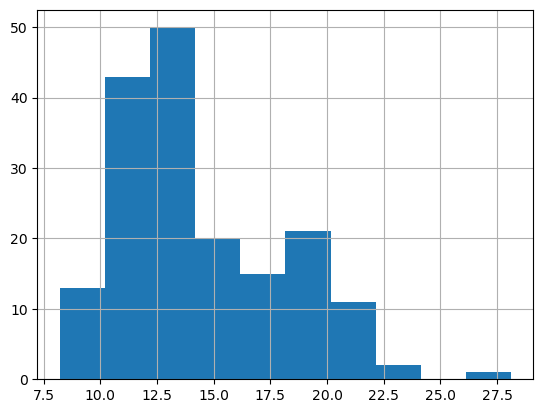

In [4]:
df['mean radius'].hist()

Yeo-Johnson Power Transform
with standarization

(array([ 4.,  7., 13., 34., 39., 22., 20., 27.,  9.,  1.]),
 array([-2.54500995, -2.03906966, -1.53312936, -1.02718906, -0.52124877,
        -0.01530847,  0.49063182,  0.99657212,  1.50251242,  2.00845271,
         2.51439301]),
 <BarContainer object of 10 artists>)

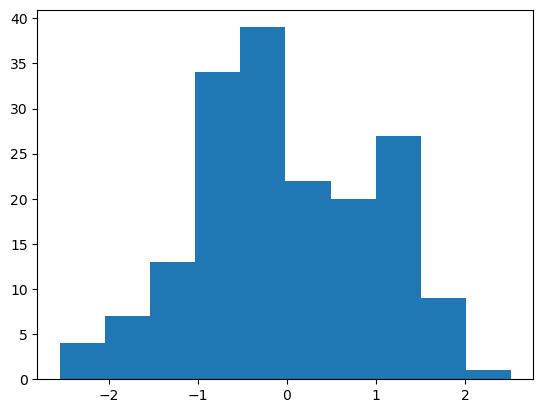

In [5]:
power = PowerTransformer(method='yeo-johnson')
t = power.fit_transform(df)
plt.hist(t[:, 0])

Without Standardization

(array([ 4.,  7., 13., 34., 39., 22., 20., 27.,  9.,  1.]),
 array([1.15402499, 1.17204759, 1.19007019, 1.20809279, 1.22611538,
        1.24413798, 1.26216058, 1.28018318, 1.29820578, 1.31622838,
        1.33425098]),
 <BarContainer object of 10 artists>)

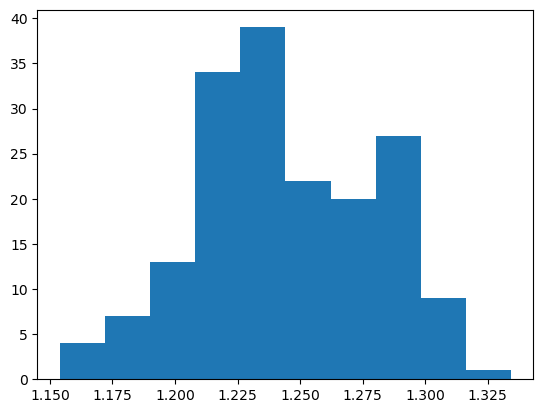

In [6]:
powerr = PowerTransformer(standardize = False, method='yeo-johnson')
t = powerr.fit_transform(df)
plt.hist(t[:, 0])


Box-cox Transformer

(array([ 4.,  7., 12., 34., 40., 22., 20., 28.,  8.,  1.]),
 array([-2.55704079, -2.04914826, -1.54125573, -1.0333632 , -0.52547066,
        -0.01757813,  0.4903144 ,  0.99820693,  1.50609946,  2.013992  ,
         2.52188453]),
 <BarContainer object of 10 artists>)

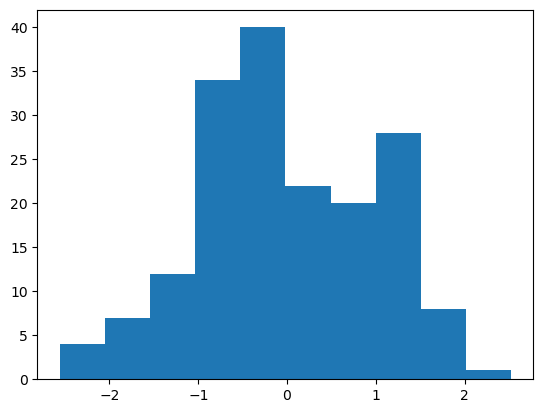

In [7]:
powerr = PowerTransformer('box-cox')
t = powerr.fit_transform(df)
plt.hist(t[:, 0])


<Axes: >

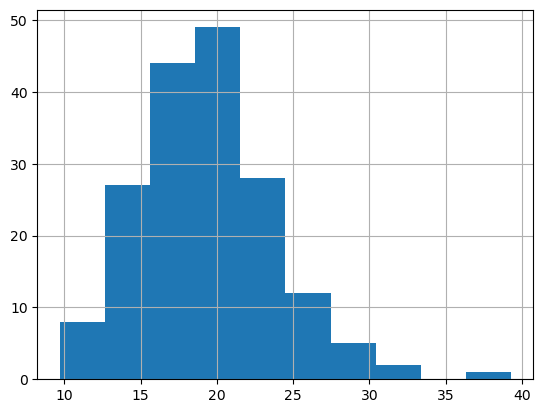

In [8]:
df['mean texture'].hist()

(array([ 2., 10., 20., 32., 37., 42., 20., 10.,  2.,  1.]),
 array([-2.8120717 , -2.2030934 , -1.5941151 , -0.9851368 , -0.3761585 ,
         0.23281979,  0.84179809,  1.45077639,  2.05975469,  2.66873299,
         3.27771129]),
 <BarContainer object of 10 artists>)

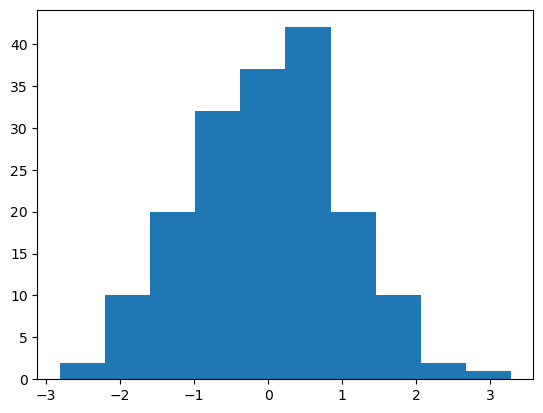

In [9]:
plt.hist(t[:, 1])

Binning

   feature1  feature2  feature3
0         1        10       100
1         2        15       200
2         3        20       300
3         4        25       400
4         5        30       500


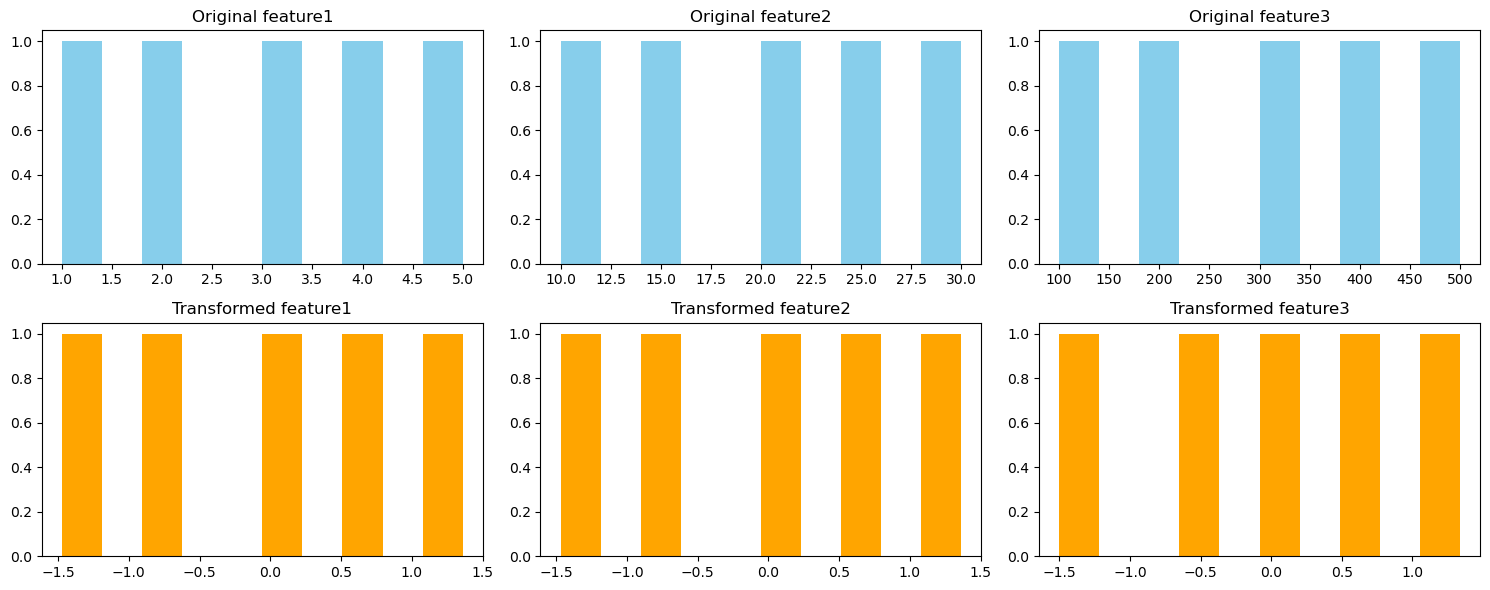

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
# Sample data (positive values only, since power transforms like Box-Cox require them)
data = {
    'feature1': [1, 2, 3, 4, 5],
    'feature2': [10, 15, 20, 25, 30],
    'feature3': [100, 200, 300, 400, 500]
}

df = pd.DataFrame(data)

print(df)
power = PowerTransformer(method= 'yeo-johnson')
power_transformed = pd.DataFrame(power.fit_transform(df), columns=df.columns)
power_transformed



fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for i, col in enumerate(df.columns):
    axes[0, i].hist(df[col], bins=10, color='skyblue')
    axes[0, i].set_title(f'Original {col}')
    
    axes[1, i].hist(power_transformed[col], bins=10, color='orange')
    axes[1, i].set_title(f'Transformed {col}')

plt.tight_layout()
plt.show()


In [11]:

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

C:\Users\Cheru\AppData\Local\Temp\ipykernel_3340\2987556298.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


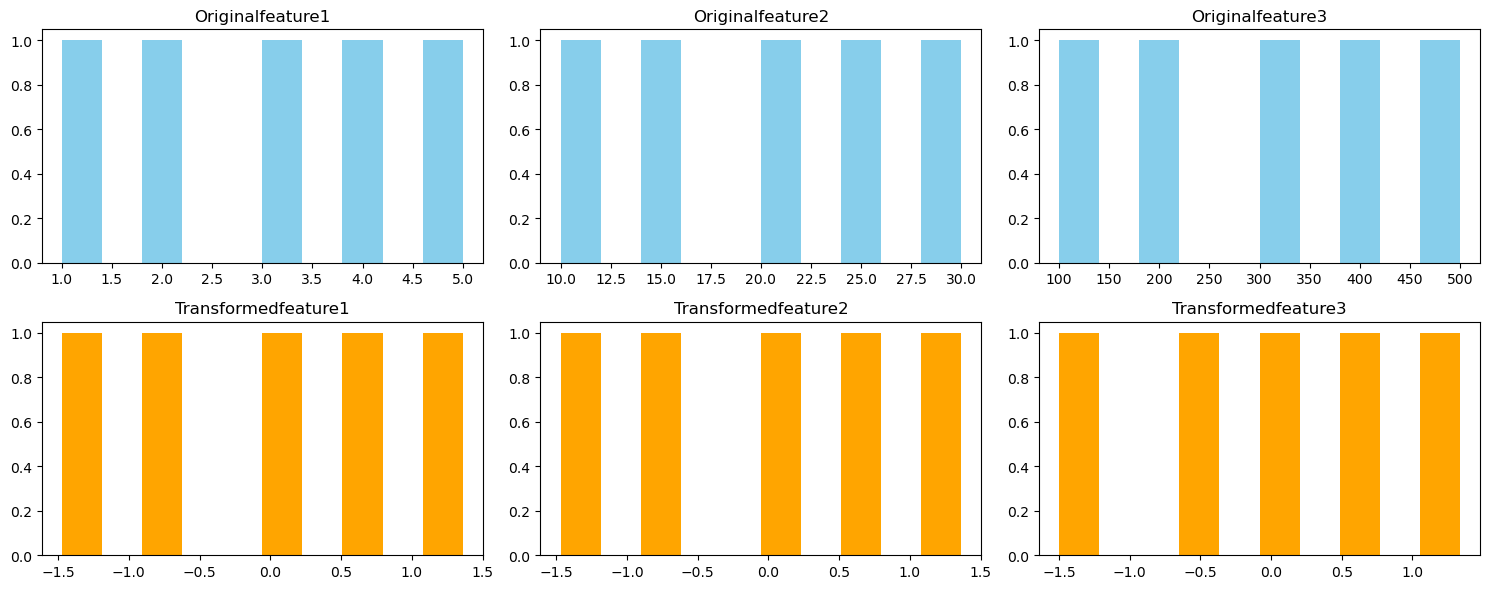

In [12]:
fig ,axes = plt.subplots(2,3 , figsize = (15,6))
for i , col in enumerate(df.columns):
    axes[0, i].hist(df[col], bins=10, color ='skyblue')
    axes[0, i].set_title(f"Original{col}")
    axes[1, i].hist(power_transformed[col ], bins=10, color ='orange')
    axes[1,i].set_title(f"Transformed{col}")
    plt.tight_layout()
    plt.show
                    



In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt

data = pd.DataFrame({
    'Store_Sales': [150, 200, 250, 300, 400, 450, 500, 550, 600, 700, 750, 900, 1000, 1100, 1250]
})

In [16]:
transformer = PowerTransformer(method='box-cox')

In [18]:
transformer.fit_transform(data)
data_transformed = pd.DataFrame(transformer.fit_transform(data), columns=data.columns)

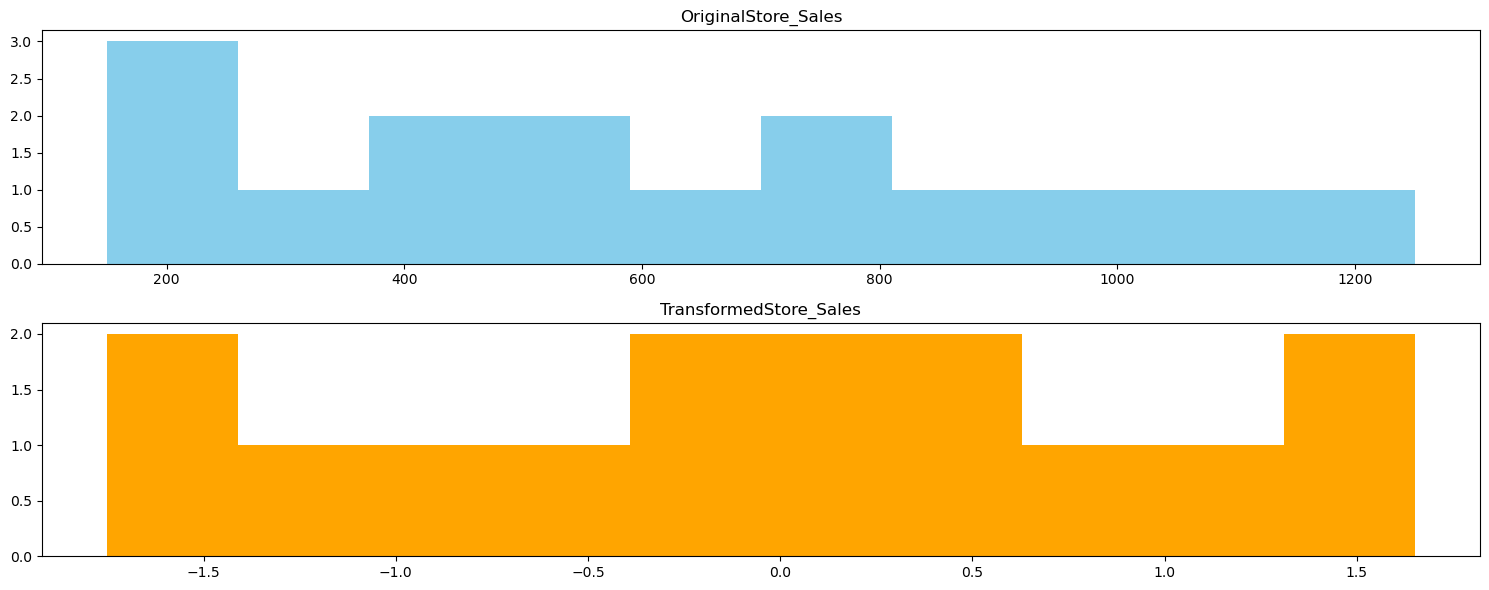

In [35]:
fig, axes = plt.subplots(2,1, figsize =(15,6))
for i ,col in enumerate(data.columns) :
    axes[0].hist(data[col], bins =10 ,color = "skyblue")
    axes[0].set_title(f"Original{col}")
    axes[1].hist(data_transformed[col], bins = 10, color = "orange")
    axes[1].set_title(f"Transformed{col}")
    plt.tight_layout()
    plt.show